In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('onlinetable_after_brazil.csv')

In [3]:
df.columns = ['rank', 'ewc', 'enc', 'country', 'player', 'china', 'france',
       'usa', 'brazil', 'greece', '? #6', '? #7', '? #8', '? #9',
       '? #10', 'total_points']

df = df[['rank', 'ewc', 'enc', 'country', 'player', 'china', 'france',
       'usa','brazil','total_points']]

In [ ]:
for col in ['china', 'france','usa','brazil','greece']:
    df[f'{col}_spot'] = df[col].apply(lambda x: int(x.split('#')[1].split(')')[0]) if type(x) is str else 65)
    df[f'{col}_points'] = df[col].apply(lambda x: int(x.split('#')[0].split('(')[0]) if type(x) is str else 0)
df

,rank,ewc,enc,country,player,china,france,usa,brazil,total_points,china_spot,china_points,france_spot,france_points,usa_spot,usa_points,brazil_spot,brazil_points
0,1,NaN,(#1),Australia,AR_Mudda,1000(#1),1000(#1),24(#41),40(#30),2064,1,1000,1,1000,41,24,30,40
1,2,NaN,(#2),Canada,CarlJr.,80(#13),500(#4),52(#24),1000(#1),1632,13,80,4,500,24,52,1,1000
2,3,NaN,(#3),Germany,MASSA_,400(#5),6(#59),400(#5),700(#2),1506,5,400,59,6,5,400,2,700
3,4,NaN,(#4),France,Binkss.,700(#2),100(#8),10(#55),600(#3),1410,2,700,8,100,55,10,3,600
4,5,NaN,NaN,France,WosileTM,64(#17),20(#45),1000(#1),300(#6),1384,17,64,45,20,1,1000,6,300
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93,94,NaN,NaN,France,chamow,NaN,6(#60),NaN,NaN,6,65,0,60,6,65,0,65,0
94,95,NaN,NaN,India,Spark.__.,4(#62),NaN,NaN,NaN,4,62,4,65,0,65,0,65,0
95,96,NaN,NaN,Norway,Intax,NaN,4(#61),NaN,NaN,4,65,0,61,4,65,0,65,0
96,97,NaN,NaN,France,V1NCH.,2(#63),NaN,NaN,NaN,2,63,2,65,0,65,0,65,0


In [ ]:
df['mean_spot'] = df[['china_spot', 'france_spot', 'usa_spot','brazil_spot', 'greece_spot']].mean(axis=1)
df['rank_by_points'] = df.index+1
df

,rank,ewc,enc,country,player,china,france,usa,brazil,total_points,china_spot,china_points,france_spot,france_points,usa_spot,usa_points,brazil_spot,brazil_points,mean_spot,rank_by_points
0,1,NaN,(#1),Australia,AR_Mudda,1000(#1),1000(#1),24(#41),40(#30),2064,1,1000,1,1000,41,24,30,40,18.25,1
1,2,NaN,(#2),Canada,CarlJr.,80(#13),500(#4),52(#24),1000(#1),1632,13,80,4,500,24,52,1,1000,10.50,2
2,3,NaN,(#3),Germany,MASSA_,400(#5),6(#59),400(#5),700(#2),1506,5,400,59,6,5,400,2,700,17.75,3
3,4,NaN,(#4),France,Binkss.,700(#2),100(#8),10(#55),600(#3),1410,2,700,8,100,55,10,3,600,17.00,4
4,5,NaN,NaN,France,WosileTM,64(#17),20(#45),1000(#1),300(#6),1384,17,64,45,20,1,1000,6,300,17.25,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
93,94,NaN,NaN,France,chamow,NaN,6(#60),NaN,NaN,6,65,0,60,6,65,0,65,0,63.75,94
94,95,NaN,NaN,India,Spark.__.,4(#62),NaN,NaN,NaN,4,62,4,65,0,65,0,65,0,64.25,95
95,96,NaN,NaN,Norway,Intax,NaN,4(#61),NaN,NaN,4,65,0,61,4,65,0,65,0,64.00,96
96,97,NaN,NaN,France,V1NCH.,2(#63),NaN,NaN,NaN,2,63,2,65,0,65,0,65,0,64.50,97


In [ ]:
toana_roh = df[['player','china_points', 'france_points', 'usa_points','brazil_points', 'greece_points','china_spot', 'france_spot', 'usa_spot','brazil_spot','greece_spot','total_points','rank_by_points','mean_spot']]
toana_roh = toana_roh.sort_values(by='mean_spot').reset_index(drop=True)
toana_roh['rank_by_mean_spot'] = toana_roh.index + 1
toana_roh

,player,china_points,france_points,usa_points,brazil_points,china_spot,france_spot,usa_spot,brazil_spot,total_points,rank_by_points,mean_spot,rank_by_mean_spot
0,CarlJr.,80,500,52,1000,13,4,24,1,1632,2,10.50,1
1,GranaDy.,600,64,200,56,3,18,7,21,920,6,12.25,2
2,BrenTM,48,48,700,92,25,25,2,10,888,7,15.50,3
3,Binkss.,700,100,10,600,2,8,55,3,1410,4,17.00,4
4,WosileTM,64,20,1000,300,17,45,1,6,1384,5,17.25,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...
93,chamow,0,6,0,0,65,60,65,65,6,94,63.75,94
94,Intax,0,4,0,0,65,61,65,65,4,96,64.00,95
95,Spark.__.,4,0,0,0,62,65,65,65,4,95,64.25,96
96,V1NCH.,2,0,0,0,63,65,65,65,2,97,64.50,97


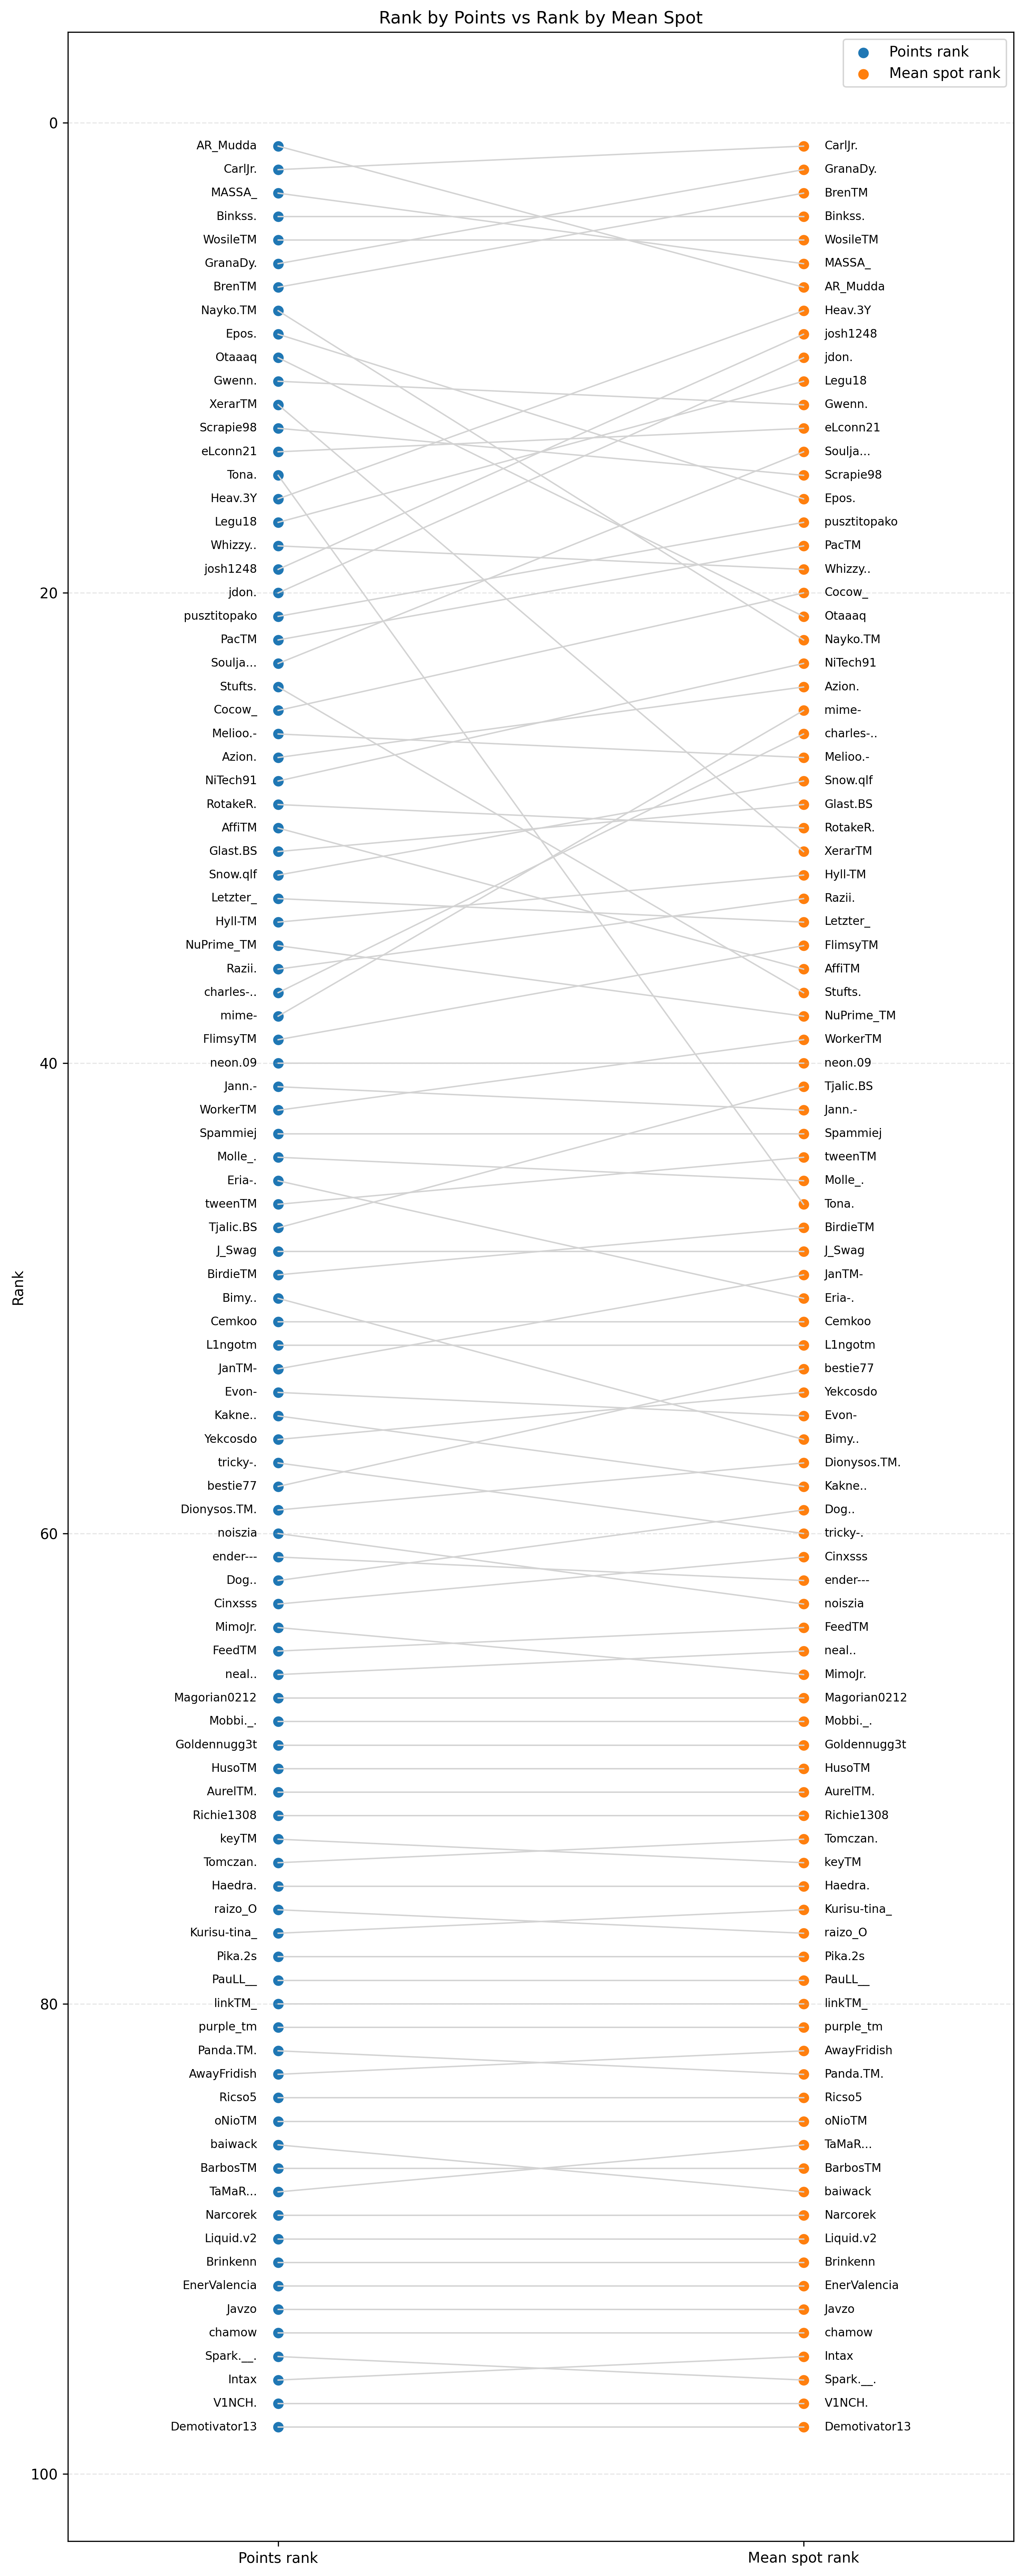

In [ ]:
fig, ax = plt.subplots(figsize=(10,25),dpi=300)

toana = toana_roh.copy()

ax.scatter(
    [0 for _ in toana.rank_by_points],
    toana.rank_by_points,
    color="tab:blue",
    s=40,
    label="Points rank"
)

ax.scatter(
    [0.05 for _ in toana.rank_by_mean_spot],
    toana.rank_by_mean_spot,
    color="tab:orange",
    s=40,
    label="Mean spot rank"
)

for idx in toana.index:
    ax.plot(
        [0, 0.05],
        [toana.rank_by_points[idx], toana.rank_by_mean_spot[idx]],
        color="lightgray",
        linewidth=1
    )

ax.legend()

ax.set_xticks([0, 0.05])
ax.set_xticklabels(["Points rank", "Mean spot rank"])
ax.set_ylabel("Rank")
ax.set_title("Rank by Points vs Rank by Mean Spot")


ax.set_xlim(-0.02, 0.07)   # a bit of padding left/right
ax.grid(axis="y", linestyle="--", alpha=0.3)

for idx in toana.index:
    label = toana.player[idx]
    ax.text(0 - 0.002, toana.rank_by_points[idx],
            label,
            ha="right", va="center", fontsize=8)
    
    ax.text(0.05+0.002, toana.rank_by_mean_spot[idx],
            label,
            ha="left", va="center", fontsize=8)
    
ax.invert_yaxis()
fig.tight_layout()
fig.savefig('20260307_averagepointsafterbrazil.png', format='png', pad_inches=0, dpi=300)